# MODELLING, TRAINING, WALKFORWARD ANALYSIS RESULTS, METRICS

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("final_model_dataset.csv")
df["date"] = pd.to_datetime(df["date"])

display(df.head())
display(df.tail())
df.shape

,date,ret_1d,ret_overnight,ret_5d,close_vs_ma5,momentum_5_20,vol_20d,vix_change,vix_ma_ratio,bn_ret_1d,nifty_bn_spread,ret_zscore,high_low_range,target
0,2022-02-01,0.013668,0.010934,0.024943,0.017099,0.027714,0.010473,-0.089749,1.074916,0.013960,-0.000292,1.553698,0.021497,1
1,2022-02-02,0.011558,0.007359,0.029057,0.022911,0.030475,0.010548,-0.066567,0.996580,0.021426,-0.009868,1.305943,0.006738,0
2,2022-02-03,-0.012362,-0.000689,0.026303,0.005061,0.046668,0.010766,0.027346,1.018580,-0.008149,-0.004213,-1.502610,0.015376,0
3,2022-02-04,-0.002500,0.001708,0.024228,-0.002184,0.037167,0.010564,-0.013570,1.002307,-0.005656,0.003156,-0.344630,0.008863,0
4,2022-02-07,-0.017281,-0.003425,-0.007281,-0.018015,0.026352,0.011139,0.081482,1.075874,-0.020467,0.003186,-2.080153,0.024245,1


,date,ret_1d,ret_overnight,ret_5d,close_vs_ma5,momentum_5_20,vol_20d,vix_change,vix_ma_ratio,bn_ret_1d,nifty_bn_spread,ret_zscore,high_low_range,target
957,2025-12-23,0.000181,0.001253,0.012260,0.007200,0.000966,0.005279,-0.030992,0.882699,-0.000075,0.000257,-0.029800,0.004374,0
958,2025-12-24,-0.001339,-0.000248,0.012532,0.003354,0.014943,0.004497,-0.020256,0.876281,-0.001955,0.000616,-0.208325,0.004338,0
959,2025-12-26,-0.003818,-0.000798,0.008783,-0.002213,0.015392,0.004570,-0.004353,0.883588,-0.002910,-0.000907,-0.499343,0.005207,0
960,2025-12-29,-0.003848,0.000808,-0.000936,-0.005867,0.009019,0.004638,0.062295,0.947322,-0.001339,-0.002509,-0.502875,0.007189,0
961,2025-12-30,-0.000125,-0.000046,-0.008924,-0.004209,0.000127,0.004637,-0.004115,0.952475,0.004054,-0.004179,-0.065819,0.003807,1


(962, 14)

In [3]:
X = df.drop(columns=["date", "target"])       #feature df
y = df["target"]                              # target df
dates = df["date"] 

print(X.shape)
print(y.shape)

(962, 12)
(962,)


In [4]:
# identify class balance

display(y.value_counts(normalize=True))     #aligns with nifty growth- more 1s
print("Majority Class:", y.value_counts().idxmax())

target
1    0.529106
0    0.470894
Name: proportion, dtype: float64

Majority Class: 1


## Split data into in-sample and out-of-sample

In [9]:
# split
is_df = df[ df["date"]<"2025-07-01" ].copy()       #in sample df
oos_df = df[ df["date"]>="2025-07-01" ].copy()     #out of sample df

print(is_df.shape)
print(oos_df.shape)

(837, 14)
(125, 14)


In [10]:
# train-test split into feature and target

X_is_train = is_df.drop(columns=["date", "target"])
y_is_train = is_df["target"]

X_oos_test = oos_df.drop(columns=["date", "target"])
y_oos_test = oos_df["target"]

print(X_is_train.shape)
print(X_oos_test.shape)

(837, 12)
(125, 12)


## Baseline Values from data

In [13]:
from sklearn.metrics import accuracy_score

In [14]:
# Majority class(1) baseline acc.

majority_pred = np.ones(len(y_oos_test))
majority_acc = accuracy_score(y_oos_test, majority_pred)

print("Majority Baseline Accuracy:", np.round(majority_acc,4))

Majority Baseline Accuracy: 0.512


In [15]:
# Persistence baseline acc.

persistence_pred = y_oos_test.shift(1).dropna()      #prev. day true => today prediction
persistence_true = y_oos_test.iloc[1:]

persistence_acc = accuracy_score(persistence_true, persistence_pred)

print("Persistence Baseline Accuracy:", np.round(persistence_acc,4))

Persistence Baseline Accuracy: 0.5887


## Split using time series split

In [18]:
# Walk forward validation required
# K-fold not used, since data from future folds would be used to train present data, defeats purpose of prediction 

In [19]:
from sklearn.model_selection import TimeSeriesSplit

In [20]:
ts = TimeSeriesSplit(n_splits=5)

In [21]:
fold = 1
for train_idx, val_idx in ts.split(X_is_train):
    print("Fold", fold)
    print("Train:", train_idx[0], "to", train_idx[-1])
    print("Validation:", val_idx[0], "to", val_idx[-1])
    fold+=1

Fold 1
Train: 0 to 141
Validation: 142 to 280
Fold 2
Train: 0 to 280
Validation: 281 to 419
Fold 3
Train: 0 to 419
Validation: 420 to 558
Fold 4
Train: 0 to 558
Validation: 559 to 697
Fold 5
Train: 0 to 697
Validation: 698 to 836


## Model development

In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [72]:
# model definition
model = XGBClassifier(
    n_estimators=90,
    max_depth=2,
    learning_rate=0.02,

    min_child_weight=10,

    subsample=0.7,
    colsample_bytree=0.8,   # increased, so that features are used more

    reg_alpha=1,
    reg_lambda=8,

    random_state=42
)

In [74]:
# training - in sample data

cv_scores = []

for fold, (train_idx, val_idx) in enumerate(ts.split(X_is_train)):

    X_train_fold = X_is_train.iloc[train_idx]
    y_train_fold = y_is_train.iloc[train_idx]

    X_val_fold = X_is_train.iloc[val_idx]
    y_val_fold = y_is_train.iloc[val_idx]

    model.fit(X_train_fold, y_train_fold)

    val_pred = model.predict(X_val_fold)
    acc = accuracy_score(y_val_fold, val_pred)
    cv_scores.append(acc)

    print(f"Fold {fold+1} Accuracy:", round(acc, 4))
    
print("Mean CV Accuracy:", round(np.mean(cv_scores),4) )

Fold 1 Accuracy: 0.5108
Fold 2 Accuracy: 0.6259
Fold 3 Accuracy: 0.5612
Fold 4 Accuracy: 0.4676
Fold 5 Accuracy: 0.4964
Mean CV Accuracy: 0.5324


In [75]:
# testset - out of sample data

model.fit(X_is_train, y_is_train)

oos_pred = model.predict(X_oos_test)
oos_prob = model.predict_proba(X_oos_test)

oos_acc = accuracy_score(y_oos_test, oos_pred)

print("OOS Accuracy:", oos_acc)

OOS Accuracy: 0.544


## Probability of Accuracies and Threshold

In [80]:
oos_prob_up = oos_prob[:, 1]

prob_df = pd.DataFrame({
    "actual": y_oos_test,
    "pred_prob_up": oos_prob_up,
    "pred_class": oos_pred
})

#display(prob_df.head(20))
#display(prob_df.tail(10))

In [83]:
# checking prob. distribution
prob_df["pred_prob_up"].describe()

count    125.000000
mean       0.581689
std        0.047379
min        0.465819
25%        0.551140
50%        0.586636
75%        0.619967
max        0.673690
Name: pred_prob_up, dtype: float64

<Axes: >

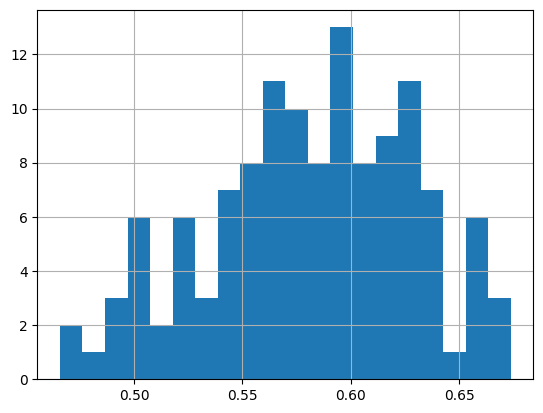

In [85]:
prob_df["pred_prob_up"].hist(bins=20)             #slight bullish bias

In [88]:
# high confidence predictions
high_conf_df = prob_df[prob_df["pred_prob_up"] > 0.60]

high_conf_acc = accuracy_score(high_conf_df["actual"], high_conf_df["pred_class"])

print("Out of 125 ot of sample days")
print("High Confidence Trades:", len(high_conf_df))
print("High Confidence Accuracy:", high_conf_acc)

Out of 125 ot of sample days
High Confidence Trades: 49
High Confidence Accuracy: 0.5510204081632653


In [90]:
thresholds = np.round( np.arange(0.45,0.65,0.01), 2)

for th in thresholds:
    temp_df = prob_df[prob_df["pred_prob_up"] > th]

    if len(temp_df) > 0:
        temp_acc = accuracy_score(temp_df["actual"],temp_df["pred_class"])

        print(f"Threshold {th} | "f"Trades: {len(temp_df)} | "f"Accuracy: {round(temp_acc,4)}")

Threshold 0.45 | Trades: 125 | Accuracy: 0.544
Threshold 0.46 | Trades: 125 | Accuracy: 0.544
Threshold 0.47 | Trades: 124 | Accuracy: 0.5484
Threshold 0.48 | Trades: 123 | Accuracy: 0.5447
Threshold 0.49 | Trades: 122 | Accuracy: 0.5492
Threshold 0.5 | Trades: 117 | Accuracy: 0.5299
Threshold 0.51 | Trades: 113 | Accuracy: 0.5487
Threshold 0.52 | Trades: 110 | Accuracy: 0.5545
Threshold 0.53 | Trades: 104 | Accuracy: 0.5385
Threshold 0.54 | Trades: 102 | Accuracy: 0.5392
Threshold 0.55 | Trades: 95 | Accuracy: 0.5368
Threshold 0.56 | Trades: 86 | Accuracy: 0.5233
Threshold 0.57 | Trades: 76 | Accuracy: 0.5395
Threshold 0.58 | Trades: 66 | Accuracy: 0.5152
Threshold 0.59 | Trades: 59 | Accuracy: 0.5424
Threshold 0.6 | Trades: 49 | Accuracy: 0.551
Threshold 0.61 | Trades: 38 | Accuracy: 0.6316
Threshold 0.62 | Trades: 31 | Accuracy: 0.6129
Threshold 0.63 | Trades: 19 | Accuracy: 0.6316
Threshold 0.64 | Trades: 13 | Accuracy: 0.6154


In [92]:
# probability threshold tuning

threshold = 0.50

oos_pred = (oos_prob_up > threshold).astype(int)

from sklearn.metrics import accuracy_score
print("Threshold Accuracy:",round(accuracy_score(y_oos_test, oos_pred), 4))

Threshold Accuracy: 0.544


## Standard classification metrics

In [96]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, roc_auc_score

auc = roc_auc_score(y_oos_test, oos_prob_up)
cm = confusion_matrix(y_oos_test, oos_pred)
bal_acc = balanced_accuracy_score(y_oos_test,oos_pred)

print("AUC:", round(auc, 4))

print("Balanced Accuracy:", round(bal_acc, 4))

print("\nConfusion Matrix:")
print(cm)

AUC: 0.5663
Balanced Accuracy: 0.5336

Confusion Matrix:
[[ 6 55]
 [ 2 62]]


In [98]:
# reduced bullish bias

## Trading backtest metrics 

In [103]:
oos_returns = oos_df["ret_1d"].reset_index(drop=True)

strategy_df = pd.DataFrame({
    "actual_return": oos_returns,
    "prediction": oos_pred
})

strategy_df["strategy_return"] = (strategy_df["actual_return"] * strategy_df["prediction"])

strategy_df.head()

,actual_return,prediction,strategy_return
0,0.000970,1,0.000970
1,-0.003461,1,-0.003461
2,-0.001890,1,-0.001890
3,0.002192,1,0.002192
4,0.000012,1,0.000012


Text(0.5, 1.0, 'Market vs Strategy Performance')

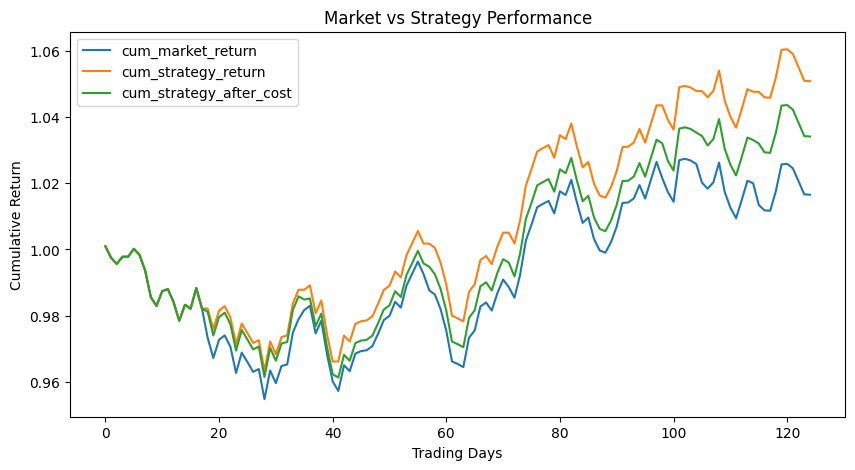

In [105]:
# cumulative returns with transaction costs

import matplotlib.pyplot as plt

txn_cost = 0.001      # 0.1% assumed cost per position change

strategy_df["trade"] = strategy_df["prediction"].diff().abs().fillna(0)

strategy_df["txn_cost"] = strategy_df["trade"] * txn_cost

strategy_df["strategy_return_after_cost"] = (strategy_df["strategy_return"] - strategy_df["txn_cost"])

strategy_df["cum_market_return"] = (1 + strategy_df["actual_return"]).cumprod()

strategy_df["cum_strategy_return"] = (1 + strategy_df["strategy_return"]).cumprod()

strategy_df["cum_strategy_after_cost"] = (1 + strategy_df["strategy_return_after_cost"]).cumprod()

strategy_df[
    [
        "cum_market_return",
        "cum_strategy_return",
        "cum_strategy_after_cost"
    ]
].plot(figsize=(10,5))

plt.xlabel("Trading Days")
plt.ylabel("Cumulative Return")

plt.title("Market vs Strategy Performance")

In [107]:
#  strategy appears to avoid some down periods & participate in stronger up periods- hence beats mkt 

In [110]:
# sharpe, hit rate, turnover, max drawdown
# using transaction-cost-adjusted returns

sharpe = (strategy_df["strategy_return_after_cost"].mean()/ strategy_df["strategy_return_after_cost"].std()) * np.sqrt(250)     # std approx. 252 trade days

hit_rate = (strategy_df["strategy_return_after_cost"] > 0).mean()

turnover = (strategy_df["prediction"].diff().abs().sum())

rolling_max = (strategy_df["cum_strategy_after_cost"].cummax())
drawdown = (strategy_df["cum_strategy_after_cost"]-rolling_max) / rolling_max

max_drawdown = drawdown.min()

print("Transaction cost accounted metrics-")
print("Sharpe Ratio:", round(sharpe,4))
print("Hit Rate:", round(hit_rate,4))
print("Turnover:", turnover)
print("Max Drawdown:", round(max_drawdown,4))

Transaction cost accounted metrics-
Sharpe Ratio: 0.9198
Hit Rate: 0.504
Turnover: 16.0
Max Drawdown: -0.0396


## Results/ Metrics Summary

In [114]:
summary_df = pd.DataFrame({
    "Metric": [
        "Majority Baseline",
        "Persistence Baseline",
        "CV Accuracy",
        "OOS Accuracy",
        "AUC",
        "Balanced Accuracy",
        "Sharpe Ratio",
        "Hit Rate",
        "Turnover",
        "Max Drawdown"
    ],

    "Value": [
        majority_acc,
        persistence_acc,
        np.mean(cv_scores),
        oos_acc,
        auc,
        bal_acc,
        sharpe,
        hit_rate,
        turnover,
        max_drawdown
    ]
})

summary_df

,Metric,Value
0,Majority Baseline,0.512000
1,Persistence Baseline,0.588710
2,CV Accuracy,0.532374
3,OOS Accuracy,0.544000
4,AUC,0.566342
5,Balanced Accuracy,0.533555
6,Sharpe Ratio,0.919798
7,Hit Rate,0.504000
8,Turnover,16.000000
9,Max Drawdown,-0.039581
